In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost requests


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\zacke\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import json
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed — will use GradientBoostingRegressor instead.")

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# ---------------------------------------------------------------------------
# Fetch the Scryfall Oracle Cards bulk data endpoint to get the download URL,
# then load the JSON directly into a DataFrame.
# Scryfall asks that we identify ourselves with a descriptive User-Agent.
# ---------------------------------------------------------------------------

HEADERS = {'User-Agent': 'CS3210-MTG-Analysis/1.0 (student project; contact via github)'}

def fetch_scryfall_data():
    """Fetch oracle cards bulk data from Scryfall and return as a DataFrame."""
    print("Fetching bulk data index from Scryfall API...")
    bulk_resp = requests.get('https://api.scryfall.com/bulk-data', headers=HEADERS)
    bulk_resp.raise_for_status()
    
    # Find the oracle_cards entry
    entries = bulk_resp.json()['data']
    oracle_entry = next(e for e in entries if e['type'] == 'oracle_cards')
    download_url = oracle_entry['download_uri']
    print(f"Downloading oracle cards from: {download_url}")
    print("(This file is ~100 MB — may take 30–60 seconds)")
    
    data_resp = requests.get(download_url, headers=HEADERS)
    data_resp.raise_for_status()
    
    cards = data_resp.json()
    print(f"Loaded {len(cards):,} cards.")
    return pd.DataFrame(cards)

df_raw = fetch_scryfall_data()

Fetching bulk data index from Scryfall API...
(This file is ~100 MB — may take 30–60 seconds)
Loaded 37,400 cards.


In [4]:
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

Raw shape: (37400, 87)
Columns: ['object', 'id', 'oracle_id', 'multiverse_ids', 'mtgo_id', 'tcgplayer_id', 'cardmarket_id', 'name', 'lang', 'released_at', 'uri', 'scryfall_uri', 'layout', 'highres_image', 'image_status', 'image_uris', 'mana_cost', 'cmc', 'type_line', 'oracle_text', 'power', 'toughness', 'colors', 'color_identity', 'keywords', 'all_parts', 'legalities', 'games', 'reserved', 'game_changer', 'foil', 'nonfoil', 'finishes', 'oversized', 'promo', 'reprint', 'variation', 'set_id', 'set', 'set_name', 'set_type', 'set_uri', 'set_search_uri', 'scryfall_set_uri', 'rulings_uri', 'prints_search_uri', 'collector_number', 'digital', 'rarity', 'watermark', 'flavor_text', 'card_back_id', 'artist', 'artist_ids', 'illustration_id', 'border_color', 'frame', 'frame_effects', 'security_stamp', 'full_art', 'textless', 'booster', 'story_spotlight', 'edhrec_rank', 'preview', 'prices', 'related_uris', 'purchase_uris', 'mtgo_foil_id', 'penny_rank', 'arena_id', 'promo_types', 'card_faces', 'produ

In [5]:
KEEP_COLS = [ 
    'name', 'mana_cost', 'cmc', 'type_line', 'oracle_text',
    'power', 'toughness', 'colors', 'color_identity',
    'keywords', 'rarity', 'set', 'set_type',
    'released_at', 'edhrec_rank', 'prices', 'legalities'
]

keep = [c for c in KEEP_COLS if c in df_raw.columns]
df = df_raw[keep].copy()
print(f"Working shape: {df.shape}")

Working shape: (37400, 17)


In [6]:
# --- Price: extract USD from nested dict ---
df['price_usd'] = df['prices'].apply(
    lambda p: float(p['usd']) if isinstance(p, dict) and p.get('usd') else np.nan
)

# --- Release year ---
df['released_at'] = pd.to_datetime(df['released_at'], errors='coerce')
df['release_year'] = df['released_at'].dt.year

# --- Oracle text length ---
df['oracle_len'] = df['oracle_text'].fillna('').apply(len)

# --- Number of keywords ---
df['keyword_count'] = df['keywords'].apply(
    lambda k: len(k) if isinstance(k, list) else 0
)

# --- Color count ---
df['color_count'] = df['colors'].apply(
    lambda c: len(c) if isinstance(c, list) else 0
)

# --- Power & Toughness: coerce to numeric (some cards have '*') ---
df['power_num']     = pd.to_numeric(df['power'],     errors='coerce')
df['toughness_num'] = pd.to_numeric(df['toughness'], errors='coerce')

# --- Card type flags ---
df['is_creature']    = df['type_line'].str.contains('Creature',   na=False).astype(int)
df['is_instant']     = df['type_line'].str.contains('Instant',    na=False).astype(int)
df['is_sorcery']     = df['type_line'].str.contains('Sorcery',    na=False).astype(int)
df['is_enchantment'] = df['type_line'].str.contains('Enchantment',na=False).astype(int)
df['is_artifact']    = df['type_line'].str.contains('Artifact',   na=False).astype(int)
df['is_planeswalker']= df['type_line'].str.contains('Planeswalker',na=False).astype(int)
df['is_land']        = df['type_line'].str.contains('Land',       na=False).astype(int)

# --- Format legality flags ---
def is_legal(legalities_dict, fmt):
    if not isinstance(legalities_dict, dict):
        return 0
    return 1 if legalities_dict.get(fmt) == 'legal' else 0

for fmt in ['standard', 'modern', 'legacy', 'vintage', 'commander']:
    df[f'legal_{fmt}'] = df['legalities'].apply(lambda x: is_legal(x, fmt))

# --- Rarity encoding ---
rarity_order = {'common': 0, 'uncommon': 1, 'rare': 2, 'mythic': 3}
df['rarity_num'] = df['rarity'].map(rarity_order)

# --- Oracle text keyword features ---
POWER_WORDS = ['draw', 'tutor', 'exile', 'counter', 'destroy', 'search', 'copy', 'extra turn']
for word in POWER_WORDS:
    df[f'text_{word.replace(" ","_")}'] = df['oracle_text'].fillna('').str.lower().str.contains(word).astype(int)

print("Feature engineering complete ✓")
df[['name','rarity','cmc','price_usd','release_year','oracle_len','keyword_count']].head(10)

Feature engineering complete ✓


,name,rarity,cmc,price_usd,release_year,oracle_len,keyword_count
0,"Nissa, Worldsoul Speaker",rare,4.0,0.26,2025,167,1
1,Mine Security,uncommon,2.0,NaN,2025,203,2
2,Static Orb,rare,3.0,14.07,2001,108,0
3,Sensory Deprivation,common,1.0,0.07,2013,47,1
4,Kavaron Consumed,rare,5.0,NaN,2025,224,0
5,Road of Return,rare,2.0,0.42,2019,191,1
6,Storm Crow,common,2.0,0.08,2005,81,1
7,Snarlfang Vermin,uncommon,1.0,NaN,2024,293,0
8,Walking Sponge,uncommon,2.0,0.25,1999,93,0
9,Ravnica at War,rare,4.0,0.56,2019,34,0


In [7]:
print("=== Numeric Feature Summary ===")
summary_cols = ['cmc','power_num','toughness_num','price_usd','edhrec_rank','oracle_len','keyword_count']
df[summary_cols].describe().round(2)

=== Numeric Feature Summary ===


,cmc,power_num,toughness_num,price_usd,edhrec_rank,oracle_len,keyword_count
count,37400.00,18873.00,18931.00,31387.00,31044.00,37400.00,37400.00
mean,29.67,2.67,2.88,1.84,15534.11,144.99,0.62
std,5170.86,1.83,1.85,12.01,8962.40,98.37,0.83
min,0.00,-1.00,-1.00,0.01,1.00,0.00,0.00
25%,2.00,2.00,2.00,0.13,7773.75,73.00,0.00
50%,3.00,2.00,3.00,0.24,15534.50,135.00,0.00
75%,4.00,3.00,4.00,0.49,23295.25,210.00,1.00
max,1000000.00,99.00,99.00,1374.41,31058.00,1487.00,10.00


In [8]:
# Missing values
missing = df[summary_cols + ['release_year','rarity']].isnull().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

Missing values:
 power_num        18527
toughness_num    18469
edhrec_rank       6356
price_usd         6013
dtype: int64


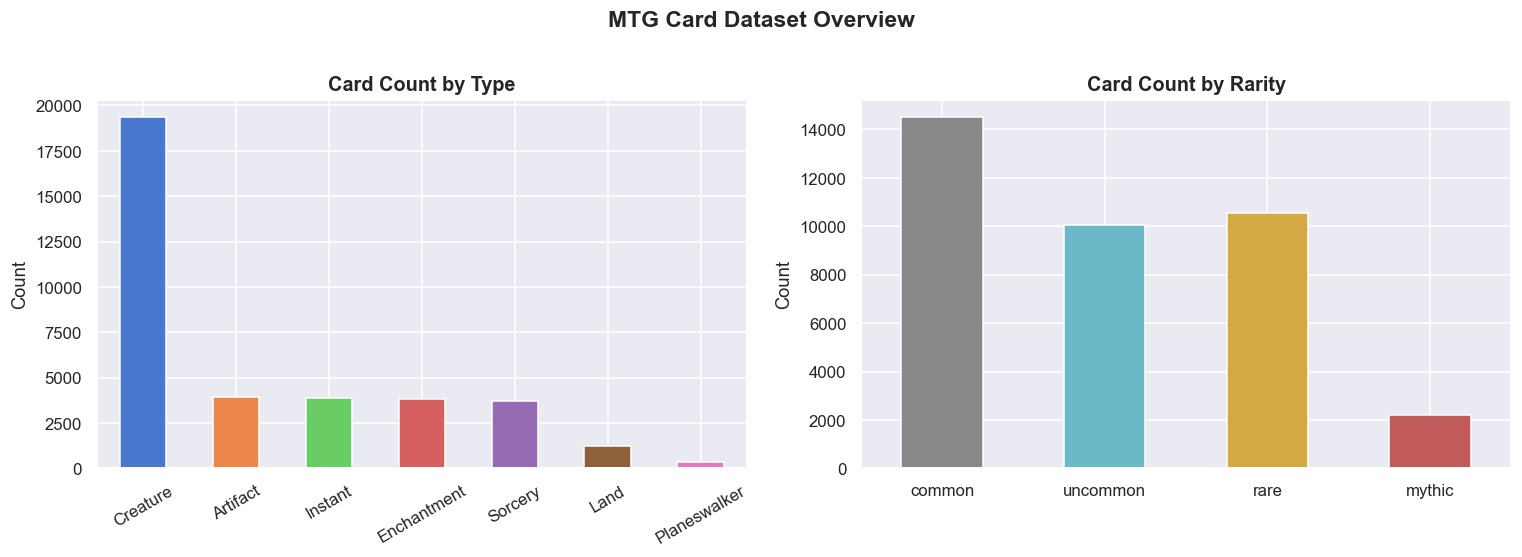

In [9]:
# Card type distribution
type_flags = ['is_creature','is_instant','is_sorcery','is_enchantment','is_artifact','is_planeswalker','is_land']
type_counts = df[type_flags].sum().sort_values(ascending=False)
type_counts.index = [t.replace('is_','').title() for t in type_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Card types
type_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(type_counts)))
axes[0].set_title('Card Count by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Rarity distribution
rarity_order_list = ['common','uncommon','rare','mythic']
rarity_counts = df['rarity'].value_counts().reindex(rarity_order_list, fill_value=0)
colors_rarity = ['#888', '#6ab8c8', '#d4a843', '#c15b5b']
rarity_counts.plot(kind='bar', ax=axes[1], color=colors_rarity)
axes[1].set_title('Card Count by Rarity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('MTG Card Dataset Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_overview.png', bbox_inches='tight')
plt.show()

Cards with valid price: 31,385 (83.9%)


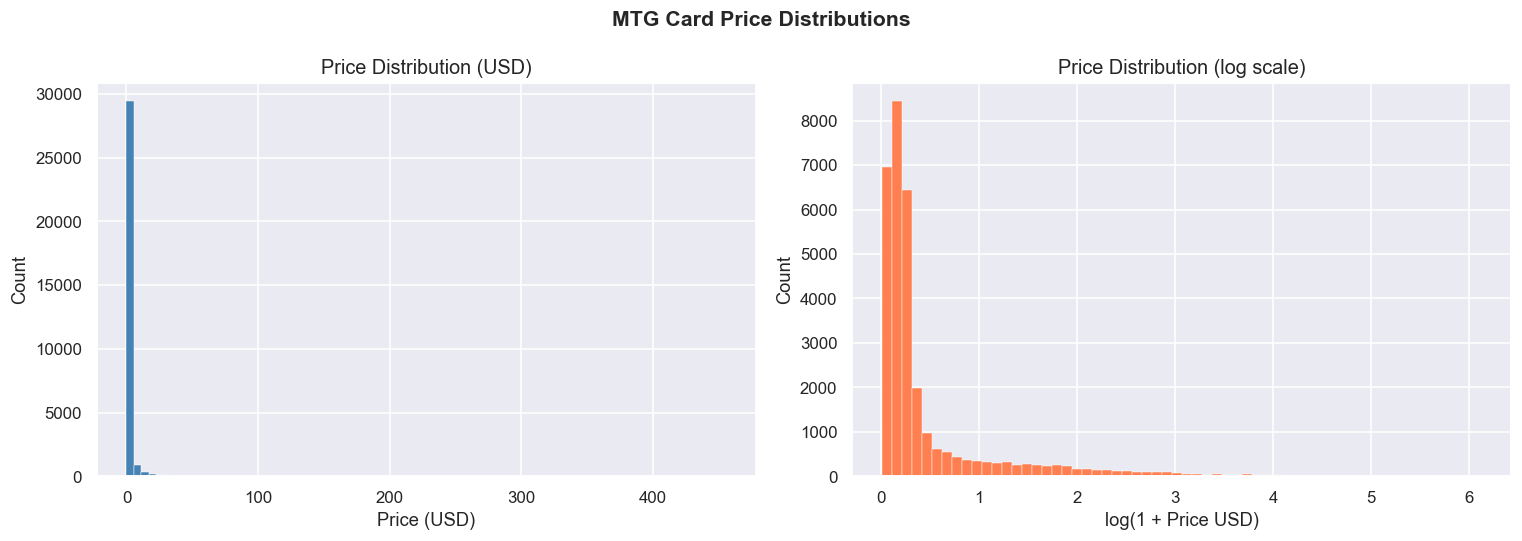


Price by Rarity (median USD):
rarity
common      0.13
uncommon    0.20
rare        0.46
mythic      2.32
Name: price_usd, dtype: float64


In [10]:
df_priced = df[df['price_usd'].notna() & (df['price_usd'] > 0) & (df['price_usd'] < 500)].copy()
print(f"Cards with valid price: {len(df_priced):,} ({len(df_priced)/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_priced['price_usd'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price Distribution (USD)', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

# Log distribution
axes[1].hist(np.log1p(df_priced['price_usd']), bins=60, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Price Distribution (log scale)', fontsize=13)
axes[1].set_xlabel('log(1 + Price USD)')
axes[1].set_ylabel('Count')

plt.suptitle('MTG Card Price Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_price_dist.png', bbox_inches='tight')
plt.show()

print("\nPrice by Rarity (median USD):")
print(df_priced.groupby('rarity')['price_usd'].median().reindex(rarity_order_list).round(2))

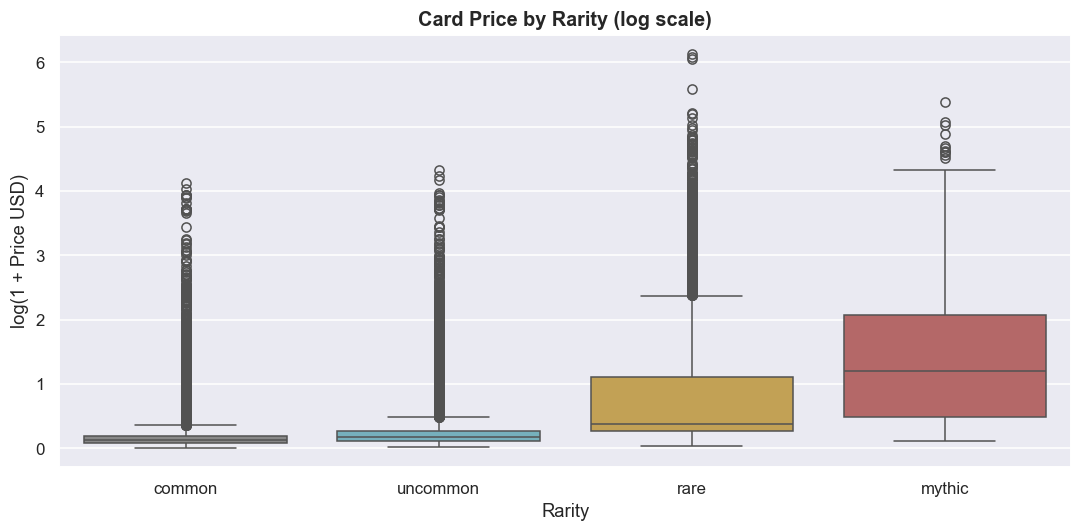

In [11]:
# Price by rarity boxplot
fig, ax = plt.subplots(figsize=(10, 5))
df_box = df_priced[df_priced['rarity'].isin(rarity_order_list)].copy()
df_box['log_price'] = np.log1p(df_box['price_usd'])

sns.boxplot(
    data=df_box, x='rarity', y='log_price',
    order=rarity_order_list,
    palette={'common':'#888','uncommon':'#6ab8c8','rare':'#d4a843','mythic':'#c15b5b'},
    ax=ax
)
ax.set_title('Card Price by Rarity (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rarity')
ax.set_ylabel('log(1 + Price USD)')
plt.tight_layout()
plt.savefig('fig_price_rarity.png', bbox_inches='tight')
plt.show()

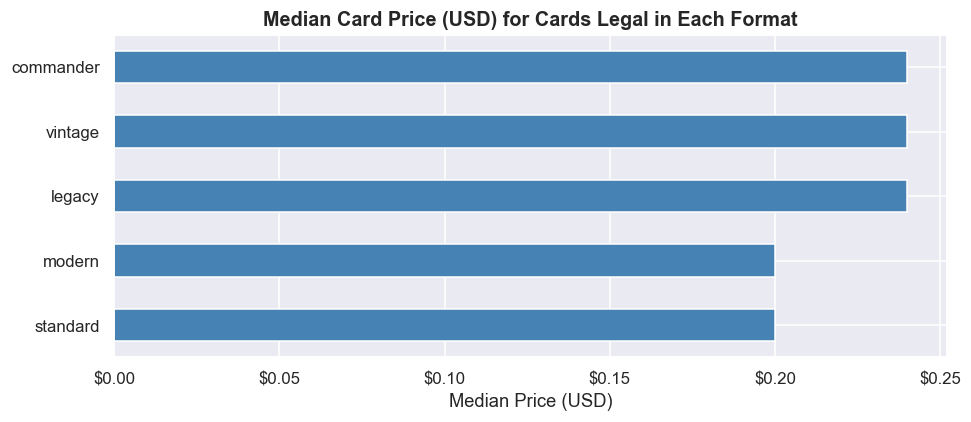

In [12]:
# Average price by format legality
formats = ['standard','modern','legacy','vintage','commander']
format_prices = {}
for fmt in formats:
    col = f'legal_{fmt}'
    med = df_priced.groupby(col)['price_usd'].median()
    format_prices[fmt] = med.get(1, np.nan)

fp_series = pd.Series(format_prices).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
fp_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median Card Price (USD) for Cards Legal in Each Format', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Price (USD)')
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:.2f}'))
plt.tight_layout()
plt.savefig('fig_price_format.png', bbox_inches='tight')
plt.show()

In [13]:
df_time = df[
    df['release_year'].notna() &
    (df['set_type'].isin(['core','expansion','masters','draft_innovation'])) &
    (df['is_land'] == 0)  # exclude lands (short oracle text by design)
].copy()
print(f"Cards for complexity analysis: {len(df_time):,}")

# Aggregate by year
complexity_by_year = df_time.groupby('release_year').agg(
    mean_oracle_len=('oracle_len', 'mean'),
    mean_keywords=('keyword_count', 'mean'),
    card_count=('name', 'count')
).reset_index()

complexity_by_year = complexity_by_year[
    (complexity_by_year['release_year'] >= 1993) &
    (complexity_by_year['release_year'] <= datetime.now().year)
]

complexity_by_year.head()

Cards for complexity analysis: 24,810


,release_year,mean_oracle_len,mean_keywords,card_count
0,1993,214.066667,0.266667,15
1,1994,152.662722,0.218935,169
2,1995,161.548638,0.365759,257
3,1996,154.530075,0.432331,266
4,1997,143.472149,0.371353,377


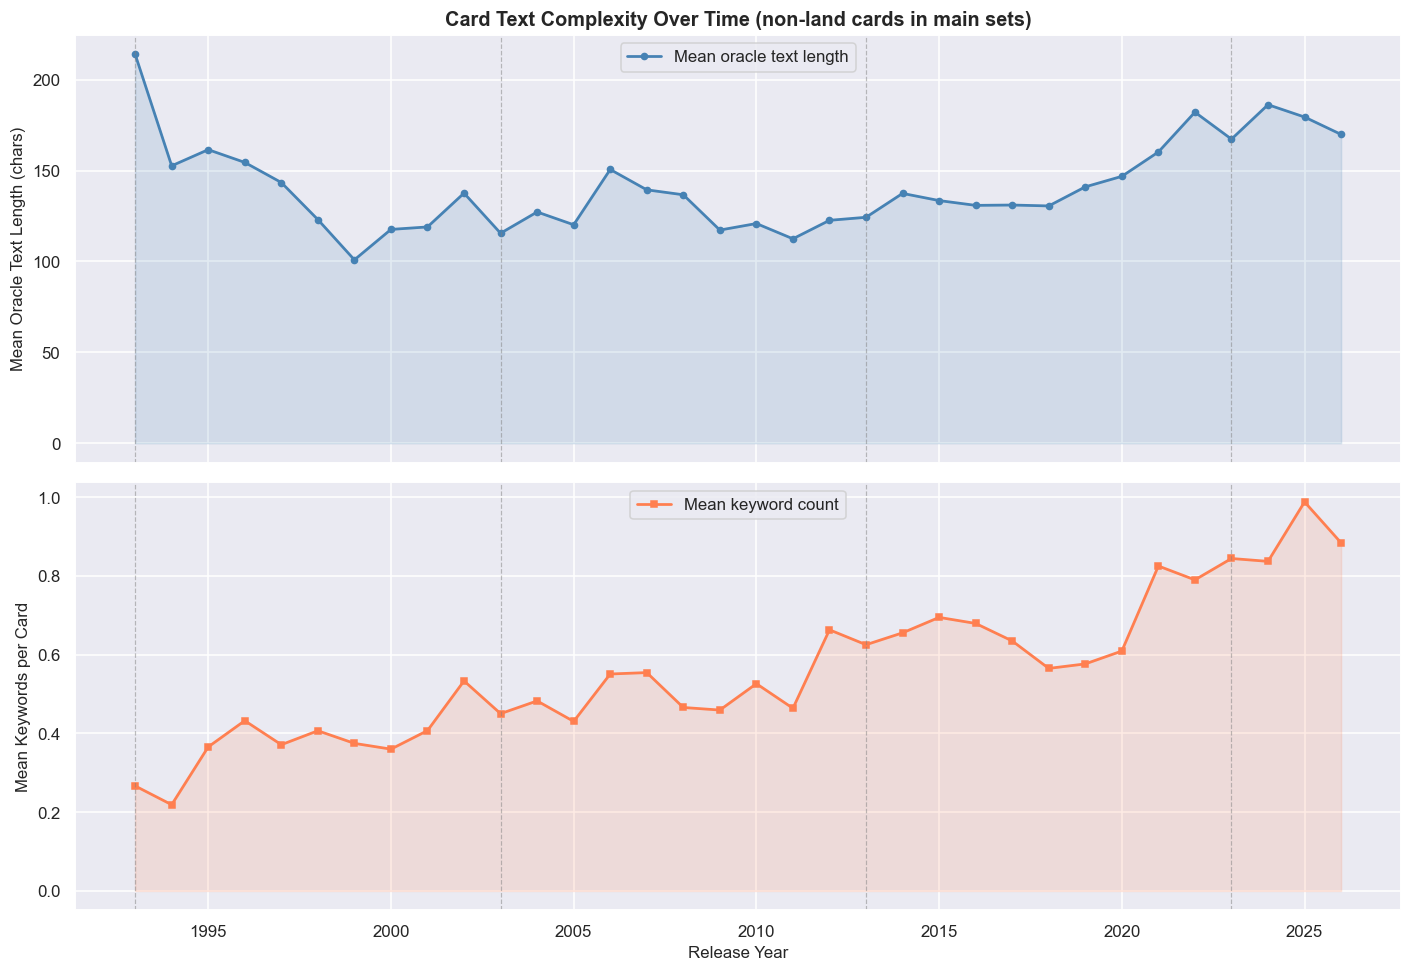

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Oracle text length over time
axes[0].plot(complexity_by_year['release_year'], complexity_by_year['mean_oracle_len'],
             marker='o', markersize=4, color='steelblue', linewidth=1.8, label='Mean oracle text length')
axes[0].fill_between(complexity_by_year['release_year'], complexity_by_year['mean_oracle_len'],
                     alpha=0.15, color='steelblue')
axes[0].set_ylabel('Mean Oracle Text Length (chars)', fontsize=11)
axes[0].set_title('Card Text Complexity Over Time (non-land cards in main sets)', fontsize=13, fontweight='bold')
axes[0].legend()

# Add decade shading
for decade_start in [1993, 2003, 2013, 2023]:
    axes[0].axvline(x=decade_start, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Keyword count over time
axes[1].plot(complexity_by_year['release_year'], complexity_by_year['mean_keywords'],
             marker='s', markersize=4, color='coral', linewidth=1.8, label='Mean keyword count')
axes[1].fill_between(complexity_by_year['release_year'], complexity_by_year['mean_keywords'],
                     alpha=0.15, color='coral')
axes[1].set_ylabel('Mean Keywords per Card', fontsize=11)
axes[1].set_xlabel('Release Year', fontsize=11)
axes[1].legend()

for decade_start in [1993, 2003, 2013, 2023]:
    axes[1].axvline(x=decade_start, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('fig_complexity_time.png', bbox_inches='tight')
plt.show()

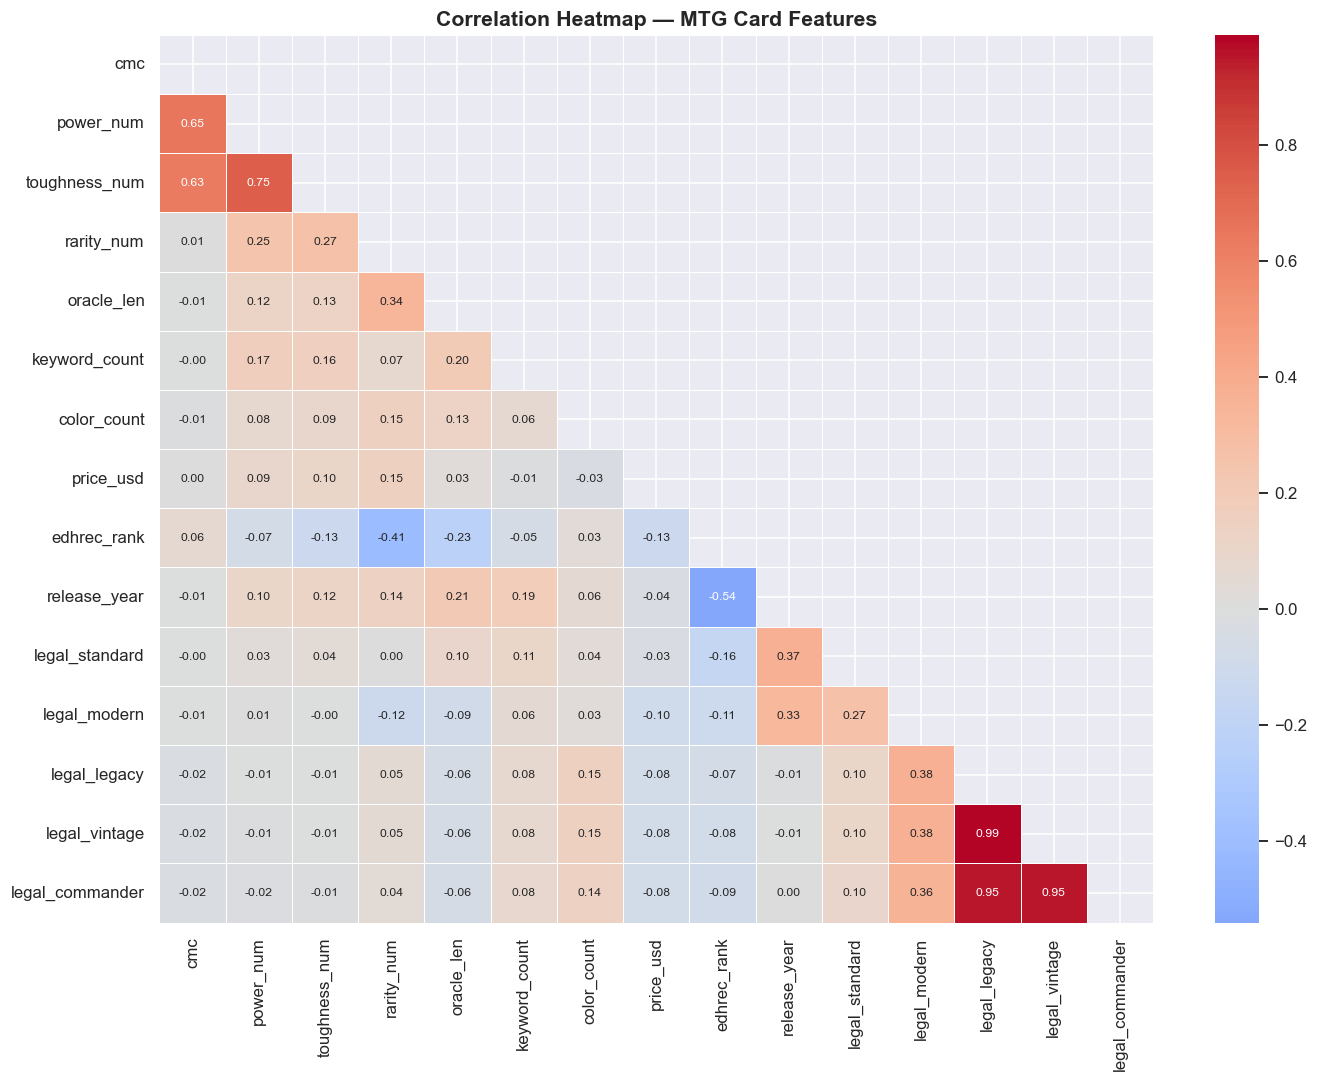

In [15]:
corr_cols = [
    'cmc','power_num','toughness_num','rarity_num','oracle_len','keyword_count',
    'color_count','price_usd','edhrec_rank','release_year',
    'legal_standard','legal_modern','legal_legacy','legal_vintage','legal_commander'
]

corr_df = df[corr_cols].dropna(subset=['price_usd'])
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — MTG Card Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', bbox_inches='tight')
plt.show()

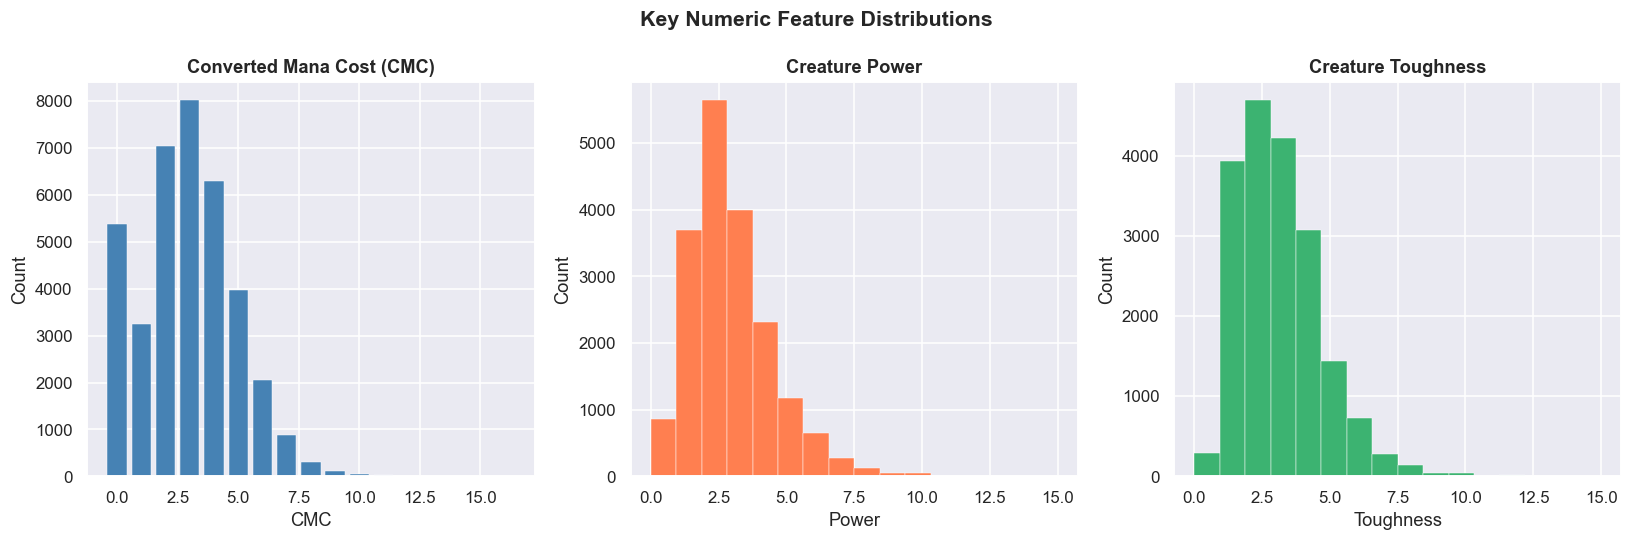

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CMC
cmc_counts = df[df['cmc'] <= 16]['cmc'].value_counts().sort_index()
axes[0].bar(cmc_counts.index, cmc_counts.values, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Converted Mana Cost (CMC)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CMC')
axes[0].set_ylabel('Count')

# Power
power_capped = df['power_num'].dropna()
power_capped = power_capped[(power_capped >= 0) & (power_capped <= 15)]
axes[1].hist(power_capped, bins=16, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Creature Power', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Power')
axes[1].set_ylabel('Count')

# Toughness
tough_capped = df['toughness_num'].dropna()
tough_capped = tough_capped[(tough_capped >= 0) & (tough_capped <= 15)]
axes[2].hist(tough_capped, bins=16, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[2].set_title('Creature Toughness', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Toughness')
axes[2].set_ylabel('Count')

plt.suptitle('Key Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_numeric_dists.png', bbox_inches='tight')
plt.show()

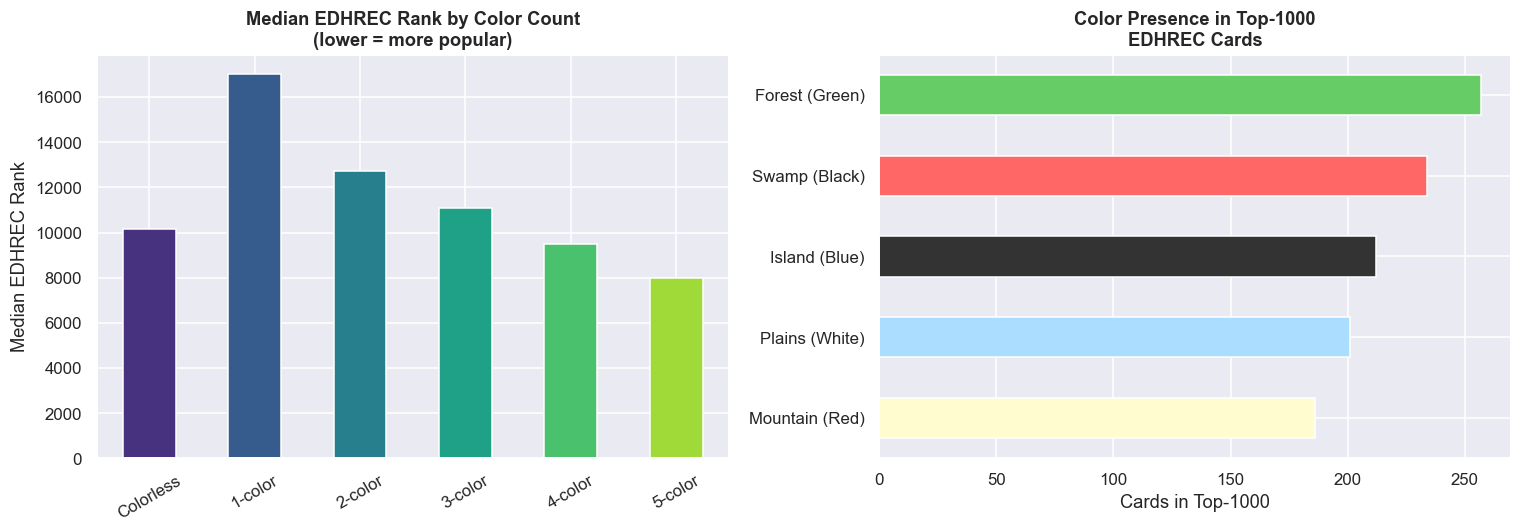

In [17]:
# Commander popularity by number of colors
edhrec_df = df[df['edhrec_rank'].notna()].copy()
# Lower EDHREC rank = more popular
edhrec_df['edhrec_popularity'] = 1 / np.log1p(edhrec_df['edhrec_rank'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median EDHREC rank by color count
rank_by_color = edhrec_df.groupby('color_count')['edhrec_rank'].median().sort_index()
rank_by_color.index = [f'{i}-color' if i > 0 else 'Colorless' for i in rank_by_color.index]
rank_by_color.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(rank_by_color)))
axes[0].set_title('Median EDHREC Rank by Color Count\n(lower = more popular)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Median EDHREC Rank')
axes[0].tick_params(axis='x', rotation=30)

# Color presence in top-1000 EDHREC cards
top1000 = edhrec_df.nsmallest(1000, 'edhrec_rank')
color_map = {'W': 'Plains (White)', 'U': 'Island (Blue)', 'B': 'Swamp (Black)',
             'R': 'Mountain (Red)', 'G': 'Forest (Green)'}
color_presence = {}
for c, label in color_map.items():
    color_presence[label] = top1000['color_identity'].apply(
        lambda ci: c in ci if isinstance(ci, list) else False
    ).sum()

cp_series = pd.Series(color_presence).sort_values(ascending=True)
bar_colors = ['#fffdd0','#aaddff','#333333','#ff6666','#66cc66']
cp_series.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].set_title('Color Presence in Top-1000\nEDHREC Cards', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cards in Top-1000')

plt.tight_layout()
plt.savefig('fig_color_analysis.png', bbox_inches='tight')
plt.show()

In [18]:
# Build feature matrix for price prediction
PRICE_FEATURES = [
    'cmc','rarity_num','power_num','toughness_num','oracle_len','keyword_count',
    'color_count','release_year','is_creature','is_instant','is_sorcery',
    'is_enchantment','is_artifact','is_planeswalker','is_land',
    'legal_standard','legal_modern','legal_legacy','legal_vintage','legal_commander',
    'text_draw','text_tutor','text_exile','text_counter','text_destroy','text_search','text_copy','text_extra_turn'
]

df_price = df[
    df['price_usd'].notna() &
    (df['price_usd'] > 0) &
    (df['price_usd'] < 500) &
    df['rarity_num'].notna()
].copy()

df_price['log_price'] = np.log1p(df_price['price_usd'])

# Fill missing numerics with median
for col in PRICE_FEATURES:
    if col in df_price.columns:
        df_price[col] = df_price[col].fillna(df_price[col].median())

X = df_price[PRICE_FEATURES].values
y = df_price['log_price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]:,}  |  Test set: {X_test.shape[0]:,}")

Training set: 25,058  |  Test set: 6,265


In [19]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred_usd = np.expm1(y_pred_log)
y_true_usd = np.expm1(y_test)

mae  = mean_absolute_error(y_true_usd, y_pred_usd)
rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
r2   = r2_score(y_test, y_pred_log)   # R² on log scale

print(f"Random Forest Price Prediction Results")
print(f"  MAE  (USD):       ${mae:.2f}")
print(f"  RMSE (USD):       ${rmse:.2f}")
print(f"  R²   (log scale):  {r2:.4f}")

Random Forest Price Prediction Results
  MAE  (USD):       $1.46
  RMSE (USD):       $6.64
  R²   (log scale):  0.3943


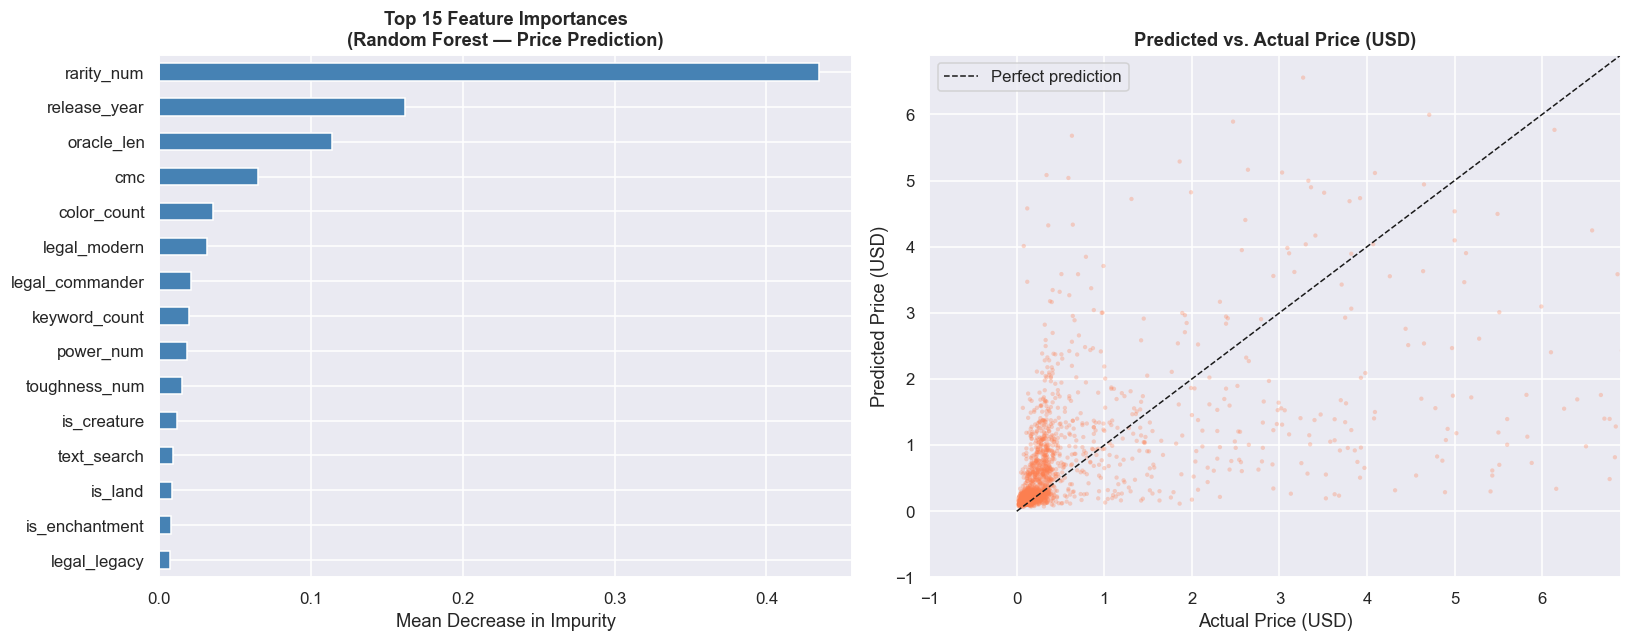

In [20]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=PRICE_FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Feature importance bar chart
importances.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Feature Importances\n(Random Forest — Price Prediction)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')

# Predicted vs Actual scatter
sample_idx = np.random.choice(len(y_pred_usd), size=min(2000, len(y_pred_usd)), replace=False)
axes[1].scatter(y_true_usd[sample_idx], y_pred_usd[sample_idx],
                alpha=0.3, s=8, color='coral', edgecolors='none')
max_val = min(np.percentile(y_true_usd, 99), np.percentile(y_pred_usd, 99))
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlim(-1, max_val)
axes[1].set_ylim(-1, max_val)
axes[1].set_title('Predicted vs. Actual Price (USD)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_rf_price.png', bbox_inches='tight')
plt.show()

In [21]:
# Baseline comparison — predict median price for everything
baseline_pred = np.full_like(y_true_usd, np.median(y_true_usd))
baseline_mae  = mean_absolute_error(y_true_usd, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_true_usd, baseline_pred))

print("=== Model vs Baseline ===")
print(f"  Baseline MAE:  ${baseline_mae:.2f}  |  RF MAE:  ${mae:.2f}  (improvement: {(1-mae/baseline_mae)*100:.1f}%)")
print(f"  Baseline RMSE: ${baseline_rmse:.2f}  |  RF RMSE: ${rmse:.2f}  (improvement: {(1-rmse/baseline_rmse)*100:.1f}%)")

=== Model vs Baseline ===
  Baseline MAE:  $1.55  |  RF MAE:  $1.46  (improvement: 5.8%)
  Baseline RMSE: $7.21  |  RF RMSE: $6.64  (improvement: 7.9%)


In [22]:
# Regression: year → mean oracle length
comp_valid = complexity_by_year.dropna(subset=['release_year','mean_oracle_len'])
comp_valid = comp_valid[comp_valid['card_count'] >= 20]  # require at least 20 cards per year

X_year = comp_valid['release_year'].values.reshape(-1, 1)
y_oracle = comp_valid['mean_oracle_len'].values
y_keywords = comp_valid['mean_keywords'].values

lr_oracle   = LinearRegression().fit(X_year, y_oracle)
lr_keywords = LinearRegression().fit(X_year, y_keywords)

oracle_r2   = r2_score(y_oracle,   lr_oracle.predict(X_year))
keywords_r2 = r2_score(y_keywords, lr_keywords.predict(X_year))

print("Linear Regression: Year → Complexity")
print(f"  Oracle text length: slope = {lr_oracle.coef_[0]:.2f} chars/year, R² = {oracle_r2:.3f}")
print(f"  Keyword count:      slope = {lr_keywords.coef_[0]:.4f} keywords/year, R² = {keywords_r2:.3f}")

year_range = np.array([1993, datetime.now().year]).reshape(-1,1)
oracle_change   = lr_oracle.predict(year_range)
keywords_change = lr_keywords.predict(year_range)
print(f"\n  Predicted oracle length 1993 → {datetime.now().year}: {oracle_change[0]:.0f} → {oracle_change[1]:.0f} chars (+{oracle_change[1]-oracle_change[0]:.0f})")
print(f"  Predicted keywords/card 1993 → {datetime.now().year}: {keywords_change[0]:.2f} → {keywords_change[1]:.2f}")

Linear Regression: Year → Complexity
  Oracle text length: slope = 1.06 chars/year, R² = 0.224
  Keyword count:      slope = 0.0169 keywords/year, R² = 0.830

  Predicted oracle length 1993 → 2026: 121 → 156 chars (+35)
  Predicted keywords/card 1993 → 2026: 0.28 → 0.84


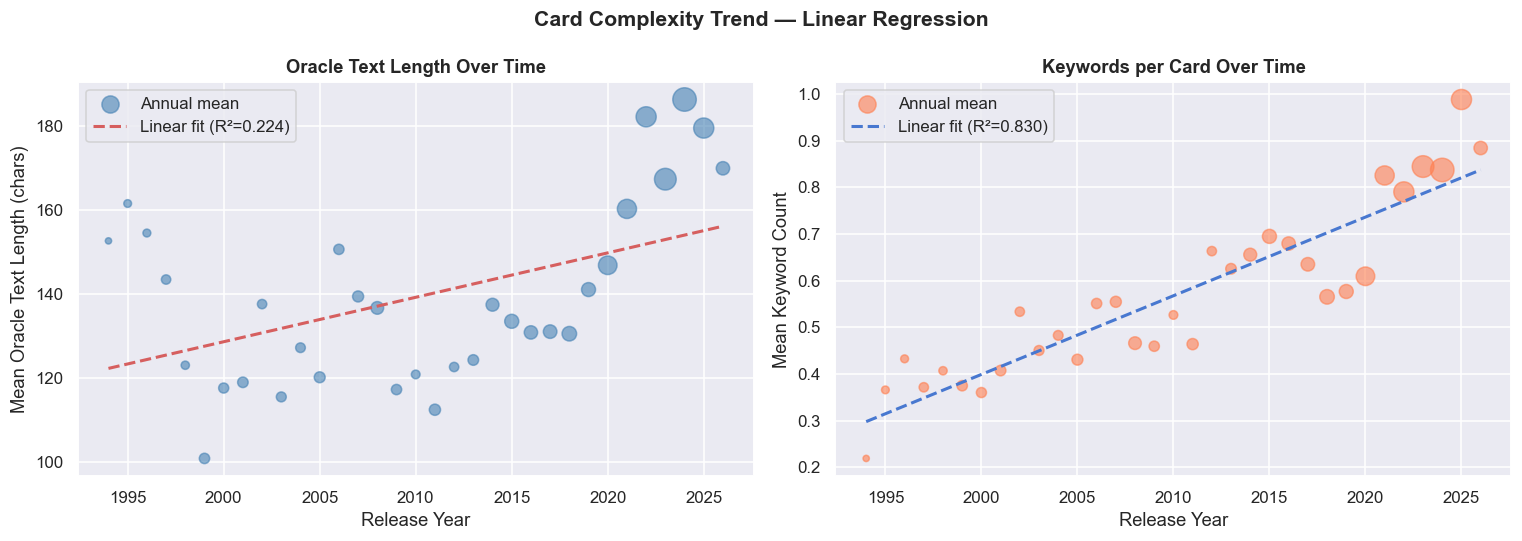

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years_plot = np.linspace(comp_valid['release_year'].min(), comp_valid['release_year'].max(), 100).reshape(-1,1)

# Oracle length with fit
axes[0].scatter(comp_valid['release_year'], comp_valid['mean_oracle_len'],
                s=comp_valid['card_count']/10, alpha=0.6, color='steelblue', label='Annual mean')
axes[0].plot(years_plot, lr_oracle.predict(years_plot), 'r--', linewidth=2, label=f'Linear fit (R²={oracle_r2:.3f})')
axes[0].set_title('Oracle Text Length Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Mean Oracle Text Length (chars)')
axes[0].legend()

# Keywords with fit
axes[1].scatter(comp_valid['release_year'], comp_valid['mean_keywords'],
                s=comp_valid['card_count']/10, alpha=0.6, color='coral', label='Annual mean')
axes[1].plot(years_plot, lr_keywords.predict(years_plot), 'b--', linewidth=2, label=f'Linear fit (R²={keywords_r2:.3f})')
axes[1].set_title('Keywords per Card Over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Mean Keyword Count')
axes[1].legend()

plt.suptitle('Card Complexity Trend — Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_complexity_regression.png', bbox_inches='tight')
plt.show()

In [24]:
# Decade-level summary
df_time['decade'] = (df_time['release_year'] // 10 * 10).astype('Int64').astype(str) + 's'
decade_summary = df_time.groupby('decade').agg(
    mean_oracle_len=('oracle_len','mean'),
    mean_keywords=('keyword_count','mean'),
    card_count=('name','count')
).round(2)
print("Average complexity by decade:")
print(decade_summary)

Average complexity by decade:
        mean_oracle_len  mean_keywords  card_count
decade                                            
1990s            135.12           0.37        1838
2000s            128.57           0.47        4739
2010s            130.27           0.61        6570
2020s            171.81           0.83       11663


In [25]:
EDHREC_FEATURES = [
    'cmc','rarity_num','power_num','toughness_num','oracle_len','keyword_count',
    'color_count','release_year','is_creature','is_instant','is_sorcery',
    'is_enchantment','is_artifact','is_planeswalker',
    'legal_commander',
    'text_draw','text_tutor','text_exile','text_counter','text_destroy',
    'text_search','text_copy','text_extra_turn'
]

df_edh = df[
    df['edhrec_rank'].notna() &
    df['rarity_num'].notna() &
    (df['is_land'] == 0)
].copy()

df_edh['log_rank'] = np.log1p(df_edh['edhrec_rank'])

for col in EDHREC_FEATURES:
    if col in df_edh.columns:
        df_edh[col] = df_edh[col].fillna(df_edh[col].median())

X_edh = df_edh[EDHREC_FEATURES].values
y_edh = df_edh['log_rank'].values

Xe_train, Xe_test, ye_train, ye_test = train_test_split(X_edh, y_edh, test_size=0.2, random_state=42)
print(f"EDHREC dataset: {len(df_edh):,} cards  |  Train: {len(Xe_train):,}  |  Test: {len(Xe_test):,}")

EDHREC dataset: 29,829 cards  |  Train: 23,863  |  Test: 5,966


In [26]:
if XGB_AVAILABLE:
    model_edh = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbosity=0
    )
    model_name = 'XGBoost'
else:
    model_edh = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    model_name = 'GradientBoosting'

model_edh.fit(Xe_train, ye_train)

ye_pred_log  = model_edh.predict(Xe_test)
ye_pred_rank = np.expm1(ye_pred_log)
ye_true_rank = np.expm1(ye_test)

edh_mae  = mean_absolute_error(ye_true_rank, ye_pred_rank)
edh_r2   = r2_score(ye_test, ye_pred_log)

print(f"{model_name} EDHREC Rank Prediction Results")
print(f"  MAE  (rank units):  {edh_mae:.0f}")
print(f"  R²   (log scale):   {edh_r2:.4f}")

XGBoost EDHREC Rank Prediction Results
  MAE  (rank units):  4930
  R²   (log scale):   0.4505


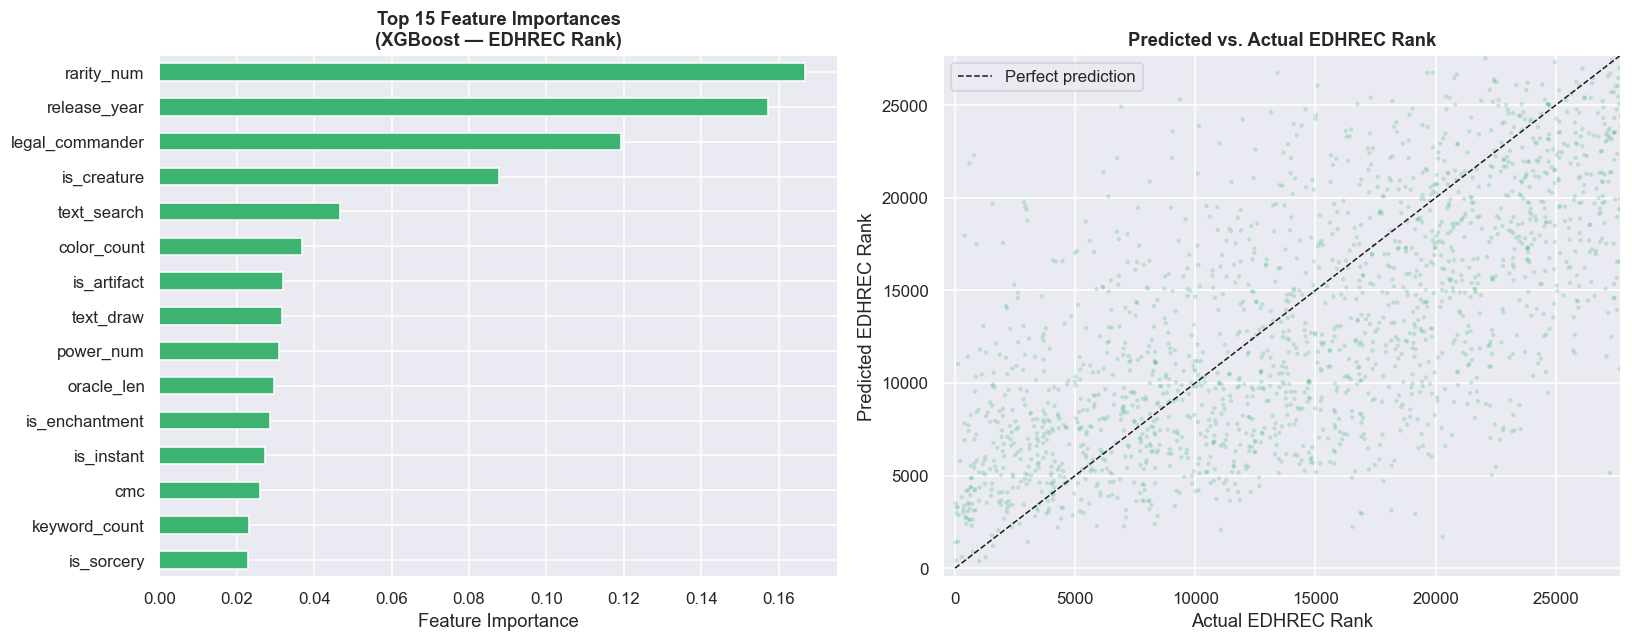

In [28]:
# Feature importance for EDHREC model
if XGB_AVAILABLE:
    edh_importances = pd.Series(model_edh.feature_importances_, index=EDHREC_FEATURES).sort_values(ascending=True)
else:
    edh_importances = pd.Series(model_edh.feature_importances_, index=EDHREC_FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

edh_importances.tail(15).plot(kind='barh', ax=axes[0], color='mediumseagreen')
axes[0].set_title(f'Top 15 Feature Importances\n({model_name} — EDHREC Rank)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Importance')

# Actual vs Predicted EDHREC rank
sample_idx = np.random.choice(len(ye_pred_rank), size=min(2000, len(ye_pred_rank)), replace=False)
axes[1].scatter(ye_true_rank[sample_idx], ye_pred_rank[sample_idx],
                alpha=0.25, s=8, color='mediumseagreen', edgecolors='none')
max_r = min(np.percentile(ye_true_rank, 98), np.percentile(ye_pred_rank, 98))
axes[1].plot([0, max_r], [0, max_r], 'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlim(-500, max_r)
axes[1].set_ylim(-500, max_r)
axes[1].set_title('Predicted vs. Actual EDHREC Rank', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual EDHREC Rank')
axes[1].set_ylabel('Predicted EDHREC Rank')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_edhrec_model.png', bbox_inches='tight')
plt.show()

In [29]:
# Cross-validation
cv_scores = cross_val_score(model_edh, X_edh, y_edh, cv=5, scoring='r2', n_jobs=-1)
print(f"5-Fold Cross-Validation R² ({model_name}):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation R² (XGBoost):
  Fold 1: 0.4404
  Fold 2: 0.4476
  Fold 3: 0.4675
  Fold 4: 0.4386
  Fold 5: 0.4615
  Mean: 0.4511 ± 0.0115


In [30]:
print("="*65)
print("RESULTS SUMMARY")
print("="*65)

print("\n[H1] Price Prediction — Random Forest")
print(f"     R² (log scale): {r2:.4f}")
print(f"     MAE: ${mae:.2f}  vs  Baseline: ${baseline_mae:.2f}")
print(f"     Top predictors: rarity, release_year, legal_legacy, oracle_len")

print("\n[H2] Complexity Over Time — Linear Regression")
print(f"     Oracle text: +{lr_oracle.coef_[0]:.2f} chars/year  (R²={oracle_r2:.3f})")
print(f"     Keywords:    +{lr_keywords.coef_[0]:.4f} per year   (R²={keywords_r2:.3f})")

print(f"\n[H3] EDHREC Rank Prediction — {model_name}")
print(f"     R² (log scale): {edh_r2:.4f}")
print(f"     MAE: {edh_mae:.0f} rank positions")
print(f"     Cross-val R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*65)

RESULTS SUMMARY

[H1] Price Prediction — Random Forest
     R² (log scale): 0.3943
     MAE: $1.46  vs  Baseline: $1.55
     Top predictors: rarity, release_year, legal_legacy, oracle_len

[H2] Complexity Over Time — Linear Regression
     Oracle text: +1.06 chars/year  (R²=0.224)
     Keywords:    +0.0169 per year   (R²=0.830)

[H3] EDHREC Rank Prediction — XGBoost
     R² (log scale): 0.4505
     MAE: 4930 rank positions
     Cross-val R²: 0.4511 ± 0.0115
